# Classificação de Risco de Crédito

Previsão de dificuldades de pagamento utilizando aprendizagem de máquina.

## 1. Visão Geral do Projeto

A análise de risco de crédito é uma importante aplicação de aprendizagem de máquina em instituições financeiras. A identificação de solicitações associadas a uma maior possibilidade de dificuldade de pagamento pode auxiliar a análise de risco e apoiar decisões mais informadas.

O objetivo deste projeto é desenvolver e comparar dois modelos supervisionados para classificação de risco de crédito:

- uma Rede Neural;
- uma Árvore de Decisão regularizada por meio do algoritmo de Minimal Cost-Complexity Pruning.

O projeto contemplará as seguintes etapas:

1. inspeção e limpeza dos dados;
2. análise exploratória;
3. engenharia de atributos;
4. construção da matriz de características \(X\) e do vetor-alvo \(y\);
5. separação dos dados em treinamento, validação e teste;
6. pré-processamento das variáveis numéricas e categóricas;
7. definição e treinamento da arquitetura da Rede Neural;
8. análise de \(E_{in}\), \(E_{out}\) e overfitting;
9. treinamento e regularização da Árvore de Decisão utilizando `ccp_alpha`;
10. avaliação dos modelos utilizando acurácia, precisão, recall e F1-score;
11. comparação e escolha do modelo com melhor capacidade de generalização.

Na primeira etapa, serão utilizadas apenas as informações presentes na solicitação atual de crédito. Após a conclusão dos modelos obrigatórios, poderão ser incorporadas informações históricas de solicitações anteriores e registros externos de crédito, com o objetivo de verificar se esses dados adicionais melhoram o desempenho preditivo.

## 2. Descrição do Conjunto de Dados

Este projeto utiliza o conjunto de dados **Home Credit Default Risk**, originalmente disponibilizado em uma competição de aprendizagem de máquina no Kaggle.

A base contém informações anonimizadas sobre solicitantes de crédito, características das solicitações atuais, solicitações anteriores e registros de crédito mantidos por outras instituições.

O principal arquivo utilizado na primeira versão do projeto será:

- `application_train.csv`: contém uma linha para cada solicitação de crédito, características do solicitante, informações financeiras e a variável-alvo `TARGET`.

Posteriormente, poderão ser incorporadas duas tabelas auxiliares:

- `bureau.csv`: contém informações sobre créditos anteriores registrados por outras instituições financeiras;
- `previous_application.csv`: contém solicitações de crédito anteriores realizadas pelos mesmos clientes.

A coluna `SK_ID_CURR` identifica cada cliente e permite relacionar a tabela principal às tabelas auxiliares.

O conjunto de dados contém variáveis numéricas e categóricas relacionadas a:

- renda do solicitante;
- valor do crédito solicitado;
- valor da parcela;
- idade e tempo de emprego;
- composição familiar;
- escolaridade;
- características da moradia;
- tipo de renda;
- tipo e finalidade da solicitação;
- pontuações externas de risco.

Os arquivos brutos estão armazenados localmente na pasta `data/raw/`. Eles não são enviados ao repositório do GitHub devido ao tamanho dos arquivos e estão protegidos pelas regras definidas no `.gitignore`.

A primeira etapa experimental utilizará somente o arquivo `application_train.csv`. As tabelas auxiliares serão agrupadas pela coluna `SK_ID_CURR` antes de serem adicionadas à tabela principal, evitando a duplicação de clientes que possuem vários registros históricos.

## 3. Definição do Problema

Este projeto será tratado como um problema supervisionado de classificação binária.

O objetivo é utilizar informações disponíveis sobre o solicitante e a solicitação de crédito para prever a classe associada à dificuldade de pagamento, conforme a definição adotada pelo conjunto de dados Home Credit Default Risk.

A variável-alvo \(y\) corresponde à coluna `TARGET`:

$$
y = \texttt{TARGET}
$$

em que:

- `TARGET = 0`: solicitação não associada à classe de dificuldade de pagamento;
- `TARGET = 1`: solicitação associada à classe de dificuldade de pagamento.

A matriz de características \(X\) será formada pelas informações do solicitante e da solicitação de crédito:

$$
X = \text{características do solicitante e da solicitação de crédito}
$$

As colunas `TARGET` e `SK_ID_CURR` não serão utilizadas como características de entrada dos modelos:

- `TARGET` representa a variável que será prevista;
- `SK_ID_CURR` é apenas o identificador de cada cliente.

A principal pergunta investigada será:

> É possível utilizar informações do solicitante e da solicitação de crédito para identificar casos associados à dificuldade de pagamento?

Após a conclusão da primeira versão do projeto, também poderá ser investigada a seguinte pergunta complementar:

> A inclusão de informações sobre créditos e solicitações anteriores melhora o desempenho dos modelos?

Serão desenvolvidos e comparados dois modelos de classificação:

1. uma Rede Neural;
2. uma Árvore de Decisão regularizada por Minimal Cost-Complexity Pruning.

Os dados serão separados em conjuntos de treinamento, validação e teste. As decisões relacionadas à arquitetura da Rede Neural, ao número de épocas, ao batch size, ao valor de `ccp_alpha` e aos demais hiperparâmetros serão tomadas utilizando apenas os conjuntos de treinamento e validação.

O conjunto de teste permanecerá isolado durante o desenvolvimento e será utilizado somente na avaliação final dos modelos.

Como a classe `TARGET = 1` pode ser menos frequente, a acurácia não será utilizada isoladamente. Os modelos serão avaliados por meio das seguintes métricas:

- acurácia;
- precisão;
- recall;
- F1-score;
- matriz de confusão.

A classe positiva será definida como `TARGET = 1`. O recall terá atenção especial, pois representa a proporção de casos da classe de dificuldade de pagamento corretamente identificados pelo modelo.

Este projeto consiste em uma análise acadêmica de modelos de aprendizagem de máquina. Os resultados não devem ser interpretados como um sistema automático de aprovação ou rejeição de crédito.

## 4. Importação das Bibliotecas

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42

candidate_roots = [Path.cwd(), Path.cwd().parent]

repo_root = next(
    (
        root
        for root in candidate_roots
        if (root / "data" / "raw").is_dir()
    ),
    None,
)

if repo_root is None:
    raise FileNotFoundError(
        "Não foi possível localizar a raiz do projeto. "
        "Abra o notebook pela raiz do repositório ou pela pasta notebooks."
    )

DATA_PATH = repo_root / "data" / "raw"
FIGURES_PATH = repo_root / "reports" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


## 5. Carregamento dos Dados

In [2]:
application_path = DATA_PATH / 'application_train.csv'

if not application_path.exists():
    raise FileNotFoundError(
        'Arquivo application_train.csv não encontrado em data/raw/.'
    )

application = pd.read_csv(application_path)

relative_application_path = application_path.relative_to(repo_root)
print(f'Dados carregados: {relative_application_path}')

Dados carregados: data\raw\application_train.csv


### 5.1 Inspeção Inicial

In [3]:
required_columns = {'SK_ID_CURR', 'TARGET'}
missing_columns = required_columns.difference(application.columns)

if missing_columns:
    raise ValueError(
        f'Colunas obrigatórias ausentes: {sorted(missing_columns)}'
    )

target_missing_count = application['TARGET'].isna().sum()

if target_missing_count > 0:
    raise ValueError(
        f'A coluna TARGET possui {target_missing_count} valores ausentes.'
    )

target_values = set(application['TARGET'].unique())

if not target_values.issubset({0, 1}):
    raise ValueError(
        f'Valores inesperados na coluna TARGET: {sorted(target_values)}'
    )

target_values_display = sorted(
    int(value) for value in target_values
)

print(f'Quantidade de linhas: {application.shape[0]:,}')
print(f'Quantidade de colunas: {application.shape[1]:,}')
print(f'Quantidade de linhas duplicadas: {application.duplicated().sum():,}')
print(f'Quantidade total de valores ausentes: {application.isna().sum().sum():,}')
print(f'Colunas obrigatórias confirmadas: {sorted(required_columns)}')
print(
    f'Valores encontrados em TARGET: '
    f'{target_values_display}'
)

Quantidade de linhas: 307,511
Quantidade de colunas: 122


Quantidade de linhas duplicadas: 0


Quantidade total de valores ausentes: 9,152,465
Colunas obrigatórias confirmadas: ['SK_ID_CURR', 'TARGET']
Valores encontrados em TARGET: [0, 1]


## 6. Análise Exploratória dos Dados

### 6.1 Estrutura Geral da Base

Esta inspeção resume a dimensão, os tipos de variáveis e o uso aproximado de memória da base sem listar individualmente todas as colunas.

In [4]:
numerical_columns = application.select_dtypes(include=np.number).columns
categorical_columns = application.select_dtypes(
    include=['object', 'category', 'string']
).columns
dtype_counts = (
    application.dtypes.astype(str)
    .value_counts()
    .rename_axis('tipo')
    .to_frame('quantidade')
)
memory_usage_mb = application.memory_usage(deep=True).sum() / (1024 ** 2)

display(application.head())
print(f'Quantidade de variáveis numéricas: {len(numerical_columns)}')
print(f'Quantidade de variáveis categóricas: {len(categorical_columns)}')
display(dtype_counts)
print(f'Memória aproximada utilizada: {memory_usage_mb:.2f} MB')

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Quantidade de variáveis numéricas: 106
Quantidade de variáveis categóricas: 16


,quantidade
tipo,
float64,65
int64,41
str,16


Memória aproximada utilizada: 536.69 MB


A base possui 307.511 registros e 122 colunas: 106 variáveis numéricas e 16 categóricas. Foram observadas 65 colunas `float64`, 41 `int64` e 16 `str`, com uso aproximado de 536,69 MB de memória.

### 6.2 Distribuição da Variável-Alvo

,quantidade,proporcao,percentual
TARGET,,,
0,282686,0.919271,91.927118
1,24825,0.080729,8.072882


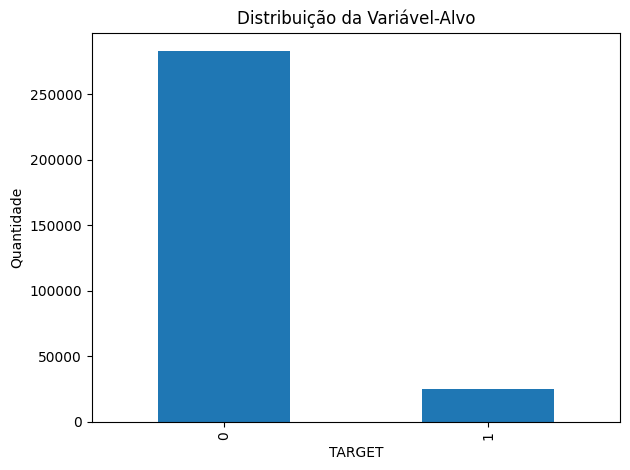

In [5]:
target_distribution = (
    application['TARGET']
    .value_counts()
    .sort_index()
    .rename('quantidade')
    .to_frame()
)
target_distribution['proporcao'] = (
    target_distribution['quantidade'] / len(application)
)
target_distribution['percentual'] = (
    target_distribution['proporcao'] * 100
)

display(target_distribution)

target_distribution['quantidade'].plot(kind='bar')
plt.title('Distribuição da Variável-Alvo')
plt.xlabel('TARGET')
plt.ylabel('Quantidade')
plt.tight_layout()
target_distribution_path = FIGURES_PATH / 'target_distribution.png'
plt.savefig(target_distribution_path)
plt.show()
plt.close()

Foram observadas 282.686 ocorrências de `TARGET = 0` (91,93%) e 24.825 de `TARGET = 1` (8,07%). A distribuição é desbalanceada, mas nenhum balanceamento foi aplicado nesta etapa.

### 6.3 Valores Ausentes

,quantidade,percentual
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_AVG,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953


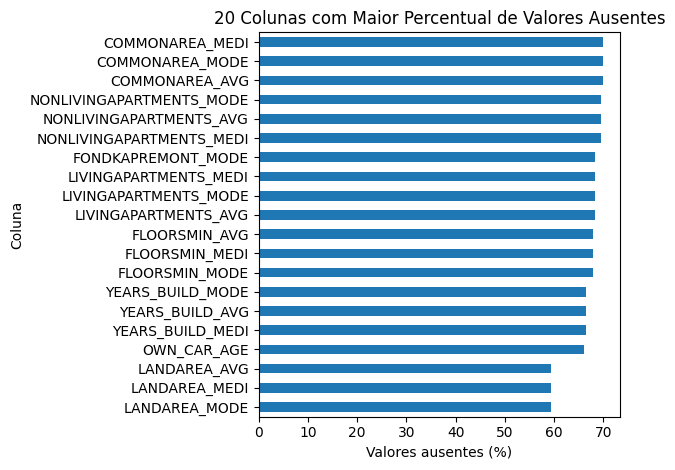

In [6]:
missing_values = pd.DataFrame({
    'quantidade': application.isna().sum(),
    'percentual': application.isna().mean() * 100,
})
top_missing_values = (
    missing_values.loc[missing_values['quantidade'] > 0]
    .nlargest(20, 'percentual')
)

display(top_missing_values)

top_missing_values.sort_values('percentual').plot.barh(
    y='percentual',
    legend=False,
)
plt.title('20 Colunas com Maior Percentual de Valores Ausentes')
plt.xlabel('Valores ausentes (%)')
plt.ylabel('Coluna')
plt.tight_layout()
top_missing_values_path = FIGURES_PATH / 'top_missing_values.png'
plt.savefig(top_missing_values_path)
plt.show()
plt.close()

Nas 20 colunas exibidas, os percentuais de ausência variam de 59,38% a 69,87%. `COMMONAREA_AVG`, `COMMONAREA_MODE` e `COMMONAREA_MEDI` apresentam o maior percentual observado, de 69,87%; nenhum valor foi removido ou imputado.

### 6.4 Resumo das Variáveis Numéricas

In [7]:
numeric_columns_of_interest = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
]
available_numeric_columns = [
    column
    for column in numeric_columns_of_interest
    if column in application.columns
]
numeric_summary = application[available_numeric_columns].describe().T

display(numeric_summary)

if 'DAYS_EMPLOYED' in application.columns:
    special_days_employed_count = int(
        application['DAYS_EMPLOYED'].eq(365243).sum()
    )
    print(
        'Ocorrências do valor 365243 em DAYS_EMPLOYED: '
        f'{special_days_employed_count:,}'
    )
else:
    print('A coluna DAYS_EMPLOYED não está presente na base.')

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
CNT_FAM_MEMBERS,307509.0,2.152665,0.910682,1.0,2.0,2.0,3.0,20.0


Ocorrências do valor 365243 em DAYS_EMPLOYED: 55,374


As oito variáveis numéricas selecionadas estão presentes na base. Em `DAYS_EMPLOYED`, o valor especial `365243` ocorre 55.374 vezes; ele foi apenas identificado, sem substituição ou limpeza.

### 6.5 Resumo das Variáveis Categóricas

In [8]:
categorical_columns = application.select_dtypes(
    include=['object', 'category', 'string']
).columns
categorical_rows = []

for column in categorical_columns:
    category_counts = application[column].value_counts(dropna=True)
    categorical_rows.append({
        'variavel': column,
        'categorias_distintas': application[column].nunique(dropna=True),
        'categoria_mais_frequente': (
            category_counts.index[0] if not category_counts.empty else pd.NA
        ),
        'frequencia_categoria_mais_frequente': (
            int(category_counts.iloc[0]) if not category_counts.empty else 0
        ),
        'valores_ausentes': int(application[column].isna().sum()),
    })

categorical_summary = (
    pd.DataFrame(
        categorical_rows,
        columns=[
            'variavel',
            'categorias_distintas',
            'categoria_mais_frequente',
            'frequencia_categoria_mais_frequente',
            'valores_ausentes',
        ],
    )
    .set_index('variavel')
    .sort_values('categorias_distintas', kind='stable')
    .head(20)
)

display(categorical_summary)

,categorias_distintas,categoria_mais_frequente,frequencia_categoria_mais_frequente,valores_ausentes
variavel,,,,
NAME_CONTRACT_TYPE,2,Cash loans,278232,0
FLAG_OWN_CAR,2,N,202924,0
FLAG_OWN_REALTY,2,Y,213312,0
EMERGENCYSTATE_MODE,2,No,159428,145755
CODE_GENDER,3,F,202448,0
HOUSETYPE_MODE,3,block of flats,150503,154297
FONDKAPREMONT_MODE,4,reg oper account,73830,210295
NAME_EDUCATION_TYPE,5,Secondary / secondary special,218391,0
NAME_FAMILY_STATUS,6,Married,196432,0


Foram identificadas 16 variáveis categóricas, com 2 a 58 categorias distintas. A tabela mostra todas elas por estarem dentro do limite de 20 e evidencia que algumas possuem valores ausentes; nenhuma codificação ou agregação foi aplicada.

## 7. Limpeza dos Dados e Engenharia de Atributos

### 7.1 Cópia de Trabalho e Correções Determinísticas

A limpeza é realizada em uma cópia da base para preservar os dados brutos. Nesta etapa são corrigidos apenas códigos com significado conhecido: `365243` em `DAYS_EMPLOYED`, que representa ausência de informação, e `XNA` em `CODE_GENDER`, que não corresponde a uma categoria válida. Duplicatas exatas também são verificadas.

Valores ausentes, categorias raras e colunas com alta ausência não são removidos ou imputados aqui, pois essas decisões deverão ser ajustadas somente após a separação dos dados.

In [9]:
application_clean = application.copy()

duplicate_rows_before = int(application_clean.duplicated().sum())

if duplicate_rows_before > 0:
    application_clean = (
        application_clean
        .drop_duplicates()
        .reset_index(drop=True)
    )

days_employed_special_count = 0

if 'DAYS_EMPLOYED' in application_clean.columns:
    days_employed_special_mask = application_clean['DAYS_EMPLOYED'].eq(365243)
    days_employed_special_count = int(days_employed_special_mask.sum())
    application_clean.loc[
        days_employed_special_mask,
        'DAYS_EMPLOYED',
    ] = np.nan

code_gender_xna_count = 0

if 'CODE_GENDER' in application_clean.columns:
    code_gender_xna_mask = application_clean['CODE_GENDER'].eq('XNA')
    code_gender_xna_count = int(code_gender_xna_mask.sum())
    application_clean.loc[
        code_gender_xna_mask,
        'CODE_GENDER',
    ] = pd.NA

print(f'Linhas duplicadas removidas: {duplicate_rows_before:,}')
print(
    'Valores 365243 convertidos em ausentes em DAYS_EMPLOYED: '
    f'{days_employed_special_count:,}'
)
print(
    'Categorias XNA convertidas em ausentes em CODE_GENDER: '
    f'{code_gender_xna_count:,}'
)
print(
    f'Dimensão após a limpeza determinística: '
    f'{application_clean.shape[0]:,} linhas x '
    f'{application_clean.shape[1]:,} colunas'
)

Linhas duplicadas removidas: 0
Valores 365243 convertidos em ausentes em DAYS_EMPLOYED: 55,374
Categorias XNA convertidas em ausentes em CODE_GENDER: 4
Dimensão após a limpeza determinística: 307,511 linhas x 122 colunas


Não foram encontradas linhas duplicadas. Foram convertidas em ausentes 55.374 ocorrências de `365243` em `DAYS_EMPLOYED` e 4 ocorrências de `XNA` em `CODE_GENDER`. A base permaneceu com 307.511 linhas e 122 colunas.

### 7.2 Engenharia de Atributos

São criados sete atributos com interpretação demográfica ou financeira: idade e tempo de emprego em anos, relações entre crédito, parcela e renda, além de medidas ajustadas pelo tamanho da família. Divisões por zero são tratadas como valores ausentes, sem imputação.

In [10]:
feature_source_columns = {
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'CNT_FAM_MEMBERS',
    'CNT_CHILDREN',
}
missing_feature_sources = feature_source_columns.difference(
    application_clean.columns
)

if missing_feature_sources:
    raise ValueError(
        'Colunas necessárias para engenharia de atributos ausentes: '
        f'{sorted(missing_feature_sources)}'
    )

def safe_ratio(numerator, denominator):
    denominator_without_zero = denominator.mask(denominator.eq(0))
    return numerator.div(denominator_without_zero)

application_clean['AGE_YEARS'] = (
    -application_clean['DAYS_BIRTH'] / 365.25
)
application_clean['EMPLOYMENT_YEARS'] = (
    -application_clean['DAYS_EMPLOYED'] / 365.25
)
application_clean['CREDIT_INCOME_RATIO'] = safe_ratio(
    application_clean['AMT_CREDIT'],
    application_clean['AMT_INCOME_TOTAL'],
)
application_clean['ANNUITY_INCOME_RATIO'] = safe_ratio(
    application_clean['AMT_ANNUITY'],
    application_clean['AMT_INCOME_TOTAL'],
)
application_clean['CREDIT_PER_FAMILY_MEMBER'] = safe_ratio(
    application_clean['AMT_CREDIT'],
    application_clean['CNT_FAM_MEMBERS'],
)
application_clean['CHILDREN_PER_FAMILY_MEMBER'] = safe_ratio(
    application_clean['CNT_CHILDREN'],
    application_clean['CNT_FAM_MEMBERS'],
)
application_clean['CREDIT_ANNUITY_RATIO'] = safe_ratio(
    application_clean['AMT_CREDIT'],
    application_clean['AMT_ANNUITY'],
)

engineered_features = [
    'AGE_YEARS',
    'EMPLOYMENT_YEARS',
    'CREDIT_INCOME_RATIO',
    'ANNUITY_INCOME_RATIO',
    'CREDIT_PER_FAMILY_MEMBER',
    'CHILDREN_PER_FAMILY_MEMBER',
    'CREDIT_ANNUITY_RATIO',
]
engineered_feature_quality = pd.DataFrame({
    'valores_ausentes': application_clean[engineered_features].isna().sum(),
    'valores_infinitos': np.isinf(
        application_clean[engineered_features]
    ).sum(),
})

print(f'Atributos criados: {len(engineered_features)}')
print(
    f'Dimensão após a engenharia de atributos: '
    f'{application_clean.shape[0]:,} linhas x '
    f'{application_clean.shape[1]:,} colunas'
)
display(engineered_feature_quality)

Atributos criados: 7
Dimensão após a engenharia de atributos: 307,511 linhas x 129 colunas


,valores_ausentes,valores_infinitos
AGE_YEARS,0,0
EMPLOYMENT_YEARS,55374,0
CREDIT_INCOME_RATIO,0,0
ANNUITY_INCOME_RATIO,12,0
CREDIT_PER_FAMILY_MEMBER,2,0
CHILDREN_PER_FAMILY_MEMBER,2,0
CREDIT_ANNUITY_RATIO,12,0


Foram adicionados sete atributos, elevando a base para 129 colunas. Nenhum atributo derivado apresentou valor infinito. Os valores ausentes observados decorrem das informações originais indisponíveis, com destaque para as 55.374 ausências de `EMPLOYMENT_YEARS` após a correção do código especial.

### 7.3 Verificação das Transformações

As estatísticas descritivas dos novos atributos são verificadas para confirmar a escala das variáveis e a ausência dos códigos especiais tratados.

In [11]:
engineered_feature_summary = (
    application_clean[engineered_features]
    .describe()
    .T
)
remaining_infinite_values = int(
    np.isinf(application_clean[engineered_features]).sum().sum()
)
remaining_days_employed_special = int(
    application_clean['DAYS_EMPLOYED'].eq(365243).sum()
)
remaining_code_gender_xna = int(
    application_clean['CODE_GENDER'].eq('XNA').sum()
)

display(engineered_feature_summary)
print(f'Valores infinitos nos atributos criados: {remaining_infinite_values:,}')
print(
    'Valores 365243 restantes em DAYS_EMPLOYED: '
    f'{remaining_days_employed_special:,}'
)
print(
    'Categorias XNA restantes em CODE_GENDER: '
    f'{remaining_code_gender_xna:,}'
)

,count,mean,std,min,25%,50%,75%,max
AGE_YEARS,307511.0,43.906900,11.947950,20.503765,33.984942,43.121150,53.886379,6.907324e+01
EMPLOYMENT_YEARS,252137.0,6.527500,6.402081,-0.000000,2.099932,4.511978,8.692676,4.904038e+01
CREDIT_INCOME_RATIO,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,8.473684e+01
ANNUITY_INCOME_RATIO,307499.0,0.180930,0.094574,0.000224,0.114782,0.162833,0.229067,1.875965e+00
CREDIT_PER_FAMILY_MEMBER,307509.0,323949.587662,259087.050339,6750.000000,135533.250000,255051.000000,437370.000000,4.031032e+06
CHILDREN_PER_FAMILY_MEMBER,307509.0,0.125502,0.199578,0.000000,0.000000,0.000000,0.333333,9.500000e-01
CREDIT_ANNUITY_RATIO,307499.0,21.612322,7.823823,8.036674,15.614496,20.000000,27.099985,4.530508e+01


Valores infinitos nos atributos criados: 0
Valores 365243 restantes em DAYS_EMPLOYED: 0
Categorias XNA restantes em CODE_GENDER: 0


A idade calculada varia de aproximadamente 20,50 a 69,07 anos, e o tempo de emprego válido chega a 49,04 anos. Não restaram valores infinitos nos atributos criados, códigos `365243` em `DAYS_EMPLOYED` ou categorias `XNA` em `CODE_GENDER`. Nenhuma imputação foi realizada.

## 8. Construção de X e y

### 8.1 Separação entre Características e Variável-Alvo

A matriz `X` é construída a partir da base limpa e enriquecida, preservando `TARGET` como a variável-alvo `y` e `SK_ID_CURR` apenas como identificador em `ids`. As características originais `DAYS_BIRTH` e `DAYS_EMPLOYED` são excluídas porque suas versões em anos, `AGE_YEARS` e `EMPLOYMENT_YEARS`, já estão presentes. Para reduzir o consumo de memória, `application_clean` é reutilizada diretamente como `X`, sem uma cópia integral. Esta etapa ainda não divide os dados nem aplica imputação, codificação ou padronização.

In [12]:
columns_excluded_from_X = {
    'TARGET',
    'SK_ID_CURR',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
}

missing_excluded_columns = columns_excluded_from_X.difference(
    application_clean.columns
)

if missing_excluded_columns:
    raise ValueError(
        f'Colunas esperadas não encontradas: {sorted(missing_excluded_columns)}'
    )

# Preserva alvo e identificadores sem copiar o DataFrame inteiro
y = application_clean.pop('TARGET')
ids = application_clean.pop('SK_ID_CURR')

# Libera a base original antes de construir X, caso ainda esteja em memória
if 'application' in globals():
    del application

# Remove in-place as versões em dias, redundantes com as versões em anos
del application_clean['DAYS_BIRTH']
del application_clean['DAYS_EMPLOYED']

X = application_clean

# Verificações de integridade
if columns_excluded_from_X.intersection(X.columns):
    raise ValueError(
        'Uma ou mais colunas que deveriam ser excluídas permaneceram em X.'
    )

if y.isna().any():
    raise ValueError('A variável TARGET possui valores ausentes.')

if set(y.unique()) != {0, 1}:
    raise ValueError(
        f'Valores inesperados em TARGET: {sorted(y.unique())}'
    )

X_numerical_count = X.select_dtypes(include=np.number).shape[1]
X_categorical_count = X.select_dtypes(
    include=['object', 'category', 'string']
).shape[1]

y_distribution = (
    y.value_counts()
    .sort_index()
    .to_frame(name='quantidade')
)

y_distribution['proporcao'] = (
    y_distribution['quantidade'] / len(y)
)

print(
    f'Dimensão de X: {X.shape[0]:,} linhas x '
    f'{X.shape[1]:,} colunas'
)

print(f'Dimensão de y: {y.shape[0]:,} valores')

print(
    f'Variáveis numéricas em X: {X_numerical_count:,}'
)

print(
    f'Variáveis categóricas em X: {X_categorical_count:,}'
)

print(
    'Colunas excluídas de X confirmadas: '
    f'{sorted(columns_excluded_from_X)}'
)

display(y_distribution)

Dimensão de X: 307,511 linhas x 125 colunas
Dimensão de y: 307,511 valores
Variáveis numéricas em X: 109
Variáveis categóricas em X: 16
Colunas excluídas de X confirmadas: ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'SK_ID_CURR', 'TARGET']


,quantidade,proporcao
TARGET,,
0,282686,0.919271
1,24825,0.080729


`X` possui 307.511 amostras e 125 características, sendo 109 numéricas e 16 categóricas. `y` possui 307.511 valores binários, com a distribuição original preservada. Os valores ausentes em `X` foram mantidos para tratamento posterior com procedimentos ajustados somente nos dados de treinamento.

## 9. Divisão em Treinamento, Validação e Teste

### 9.1 Estratégia de Divisão

A base rotulada é dividida em 70% para treinamento, 15% para validação e 15% para teste. Essa proporção mantém uma quantidade ampla de exemplos para o ajuste dos modelos e, ao mesmo tempo, reserva conjuntos independentes e suficientemente grandes para as decisões de desenvolvimento e para a avaliação final.

A divisão é estratificada por `TARGET` nas duas etapas para preservar o desbalanceamento original entre as classes. Primeiro, os índices são separados em 85% para treinamento e validação e 15% para teste; em seguida, a parcela de 85% é dividida nas proporções finais de 70% e 15%. A separação prévia dos índices reduz a necessidade de DataFrames intermediários de grande porte e preserva os índices originais para verificação de sobreposição.

O conjunto de validação será utilizado para escolhas de desenvolvimento e hiperparâmetros. O conjunto de teste permanecerá isolado até a avaliação final e não participará de nenhuma decisão de modelagem ou pré-processamento. O arquivo `application_test.csv` não é utilizado como teste acadêmico porque não possui `TARGET` e, portanto, não permite calcular as métricas de classificação.

Nenhuma transformação que aprende parâmetros dos dados é aplicada nesta seção. Na seção 10, imputação, codificação e padronização serão ajustadas exclusivamente com `X_train` e apenas aplicadas aos conjuntos de validação e teste.

In [13]:
from sklearn.model_selection import train_test_split

original_row_count = len(y)
indices = np.arange(original_row_count)

idx_train_val, idx_test = train_test_split(
    indices,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

idx_train, idx_val = train_test_split(
    idx_train_val,
    test_size=0.15 / 0.85,
    stratify=y.iloc[idx_train_val],
    random_state=RANDOM_STATE,
)

# Materializa cada subconjunto apenas uma vez e preserva os índices originais
X_train = X.iloc[idx_train]
X_val = X.iloc[idx_val]
X_test = X.iloc[idx_test]

y_train = y.iloc[idx_train]
y_val = y.iloc[idx_val]
y_test = y.iloc[idx_test]

ids_train = ids.iloc[idx_train]
ids_val = ids.iloc[idx_val]
ids_test = ids.iloc[idx_test]

# Verificações de cobertura, exclusividade e alinhamento
split_row_count = len(X_train) + len(X_val) + len(X_test)

if split_row_count != original_row_count:
    raise ValueError(
        'A soma das linhas dos subconjuntos difere do total original.'
    )

index_groups = {
    'Treino': idx_train,
    'Validação': idx_val,
    'Teste': idx_test,
}

for split_name, split_indices in index_groups.items():
    if np.unique(split_indices).size != len(split_indices):
        raise ValueError(
            f'Foram encontrados índices duplicados em {split_name}.'
        )

overlap_sizes = {
    'treino e validação': np.intersect1d(
        idx_train,
        idx_val,
        assume_unique=True,
    ).size,
    'treino e teste': np.intersect1d(
        idx_train,
        idx_test,
        assume_unique=True,
    ).size,
    'validação e teste': np.intersect1d(
        idx_val,
        idx_test,
        assume_unique=True,
    ).size,
}

if any(overlap_sizes.values()):
    raise ValueError(
        f'Foi detectada sobreposição entre subconjuntos: {overlap_sizes}'
    )

combined_indices = np.concatenate([
    idx_train,
    idx_val,
    idx_test,
])
assignment_counts = np.bincount(
    combined_indices,
    minlength=original_row_count,
)

if not np.all(assignment_counts == 1):
    raise ValueError(
        'Cada registro deve aparecer exatamente uma vez nos subconjuntos.'
    )

split_objects = {
    'Treino': (X_train, y_train, ids_train),
    'Validação': (X_val, y_val, ids_val),
    'Teste': (X_test, y_test, ids_test),
}

for split_name, (X_split, y_split, ids_split) in split_objects.items():
    if not (len(X_split) == len(y_split) == len(ids_split)):
        raise ValueError(
            f'X, y e ids possuem tamanhos diferentes em {split_name}.'
        )

    if not (
        X_split.index.equals(y_split.index)
        and X_split.index.equals(ids_split.index)
    ):
        raise ValueError(
            f'X, y e ids não estão alinhados em {split_name}.'
        )

original_target_1_rate = float(y.mean())
target_1_rates = {
    split_name: float(y_split.mean())
    for split_name, (_, y_split, _) in split_objects.items()
}
stratification_tolerance = 0.001

if any(
    abs(rate - original_target_1_rate) > stratification_tolerance
    for rate in target_1_rates.values()
):
    raise ValueError(
        'A proporção de TARGET = 1 não foi preservada pela estratificação.'
    )

# Confirma, coluna a coluna, que o teste é uma seleção inalterada de X
test_untouched = (
    X_test.index.equals(X.index[idx_test])
    and X_test.columns.equals(X.columns)
    and X_test.dtypes.equals(X.dtypes)
    and all(
        X_test[column].equals(X[column].iloc[idx_test])
        for column in X.columns
    )
)

if not test_untouched:
    raise ValueError(
        'O conjunto de teste difere da seleção original antes do pré-processamento.'
    )

def build_split_summary(split_name, y_split):
    target_counts = y_split.value_counts()
    return {
        'conjunto': split_name,
        'registros': len(y_split),
        'percentual': len(y_split) / original_row_count * 100,
        'TARGET 0': int(target_counts.get(0, 0)),
        'TARGET 1': int(target_counts.get(1, 0)),
        'percentual TARGET 1': float(y_split.mean() * 100),
    }

split_summary = pd.DataFrame([
    build_split_summary('Treino', y_train),
    build_split_summary('Validação', y_val),
    build_split_summary('Teste', y_test),
]).set_index('conjunto')

split_summary_display = split_summary.copy()
split_summary_display['percentual'] = (
    split_summary_display['percentual'].map(lambda value: f'{value:.2f}%')
)
split_summary_display['percentual TARGET 1'] = (
    split_summary_display['percentual TARGET 1']
    .map(lambda value: f'{value:.4f}%')
)

# As próximas seções utilizam apenas os subconjuntos separados
if 'application_clean' in globals():
    del application_clean

del X, y, ids, indices, idx_train_val
del combined_indices, assignment_counts, split_objects

print(f'Total de registros preservado: {split_row_count:,}')
print(
    'Sobreposição entre treino, validação e teste: '
    f'{sum(overlap_sizes.values())}'
)
print('Cada registro foi atribuído exatamente uma vez: confirmado')
print('Alinhamento entre X, y e ids em cada conjunto: confirmado')
print('Estratificação de TARGET preservada: confirmada')
print('Conjunto de teste sem transformações aprendidas: confirmado')
display(split_summary_display)

Total de registros preservado: 307,511
Sobreposição entre treino, validação e teste: 0
Cada registro foi atribuído exatamente uma vez: confirmado
Alinhamento entre X, y e ids em cada conjunto: confirmado
Estratificação de TARGET preservada: confirmada
Conjunto de teste sem transformações aprendidas: confirmado


,registros,percentual,TARGET 0,TARGET 1,percentual TARGET 1
conjunto,,,,,
Treino,215257,70.00%,197880,17377,8.0727%
Validação,46127,15.00%,42403,3724,8.0734%
Teste,46127,15.00%,42403,3724,8.0734%


A tabela confirma a divisão estratificada em treinamento, validação e teste, com preservação da proporção minoritária de `TARGET`. As verificações garantem cobertura integral dos registros, ausência de sobreposição e alinhamento entre características, alvos e identificadores. O conjunto de teste permanece sem transformações aprendidas e isolado para a avaliação final. Após a divisão, as estruturas completas originais são liberadas da memória, pois as etapas seguintes utilizarão exclusivamente `X_train`, `X_val`, `X_test` e seus vetores correspondentes.

## 10. Pré-processamento dos Dados

### 10.1 Seleção de Variáveis a partir do Treinamento

As colunas com pelo menos 60% de valores ausentes são removidas, mantendo variáveis com no mínimo 40% de observações disponíveis. O percentual de ausência é calculado exclusivamente em `X_train`; as mesmas colunas são apenas removidas de validação e teste, sem recalcular o critério nesses conjuntos.

Após esse filtro, também são identificadas somente no treinamento as colunas com `nunique(dropna=True) <= 1`, pois não apresentam variação útil. Não é utilizada correlação com `TARGET` nem qualquer seleção supervisionada.

In [14]:
MISSING_THRESHOLD = 0.60

original_feature_count = X_train.shape[1]
missing_rates_train = X_train.isna().mean()
columns_removed_missing = sorted(
    missing_rates_train[
        missing_rates_train >= MISSING_THRESHOLD
    ].index.tolist()
)

columns_after_missing = [
    column
    for column in X_train.columns
    if column not in columns_removed_missing
]
columns_removed_constant = sorted([
    column
    for column in columns_after_missing
    if X_train[column].nunique(dropna=True) <= 1
])

columns_removed_preprocessing = (
    columns_removed_missing + columns_removed_constant
)

# Aplica aos três conjuntos apenas as decisões aprendidas no treino
for split_features in (X_train, X_val, X_test):
    split_features.drop(
        columns=columns_removed_preprocessing,
        inplace=True,
    )

remaining_feature_count = X_train.shape[1]
numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=['object', 'category', 'string']
).columns.tolist()

if not (
    X_train.columns.equals(X_val.columns)
    and X_train.columns.equals(X_test.columns)
):
    raise ValueError(
        'Treino, validação e teste possuem colunas diferentes.'
    )

if len(numerical_features) + len(categorical_features) != remaining_feature_count:
    raise ValueError(
        'Uma ou mais colunas não foram classificadas como numéricas ou categóricas.'
    )

forbidden_features = {
    'TARGET',
    'SK_ID_CURR',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
}

if forbidden_features.intersection(X_train.columns):
    raise ValueError(
        'Uma ou mais colunas proibidas permaneceram nas características.'
    )

print(f'Variáveis antes dos filtros: {original_feature_count:,}')
print(
    'Colunas removidas por ausência >= 60%: '
    f'{len(columns_removed_missing):,}'
)
print(f'Nomes: {columns_removed_missing}')
print(
    'Colunas constantes ou sem informação removidas: '
    f'{len(columns_removed_constant):,}'
)
print(f'Nomes: {columns_removed_constant}')
print(f'Variáveis restantes: {remaining_feature_count:,}')
print(f'Variáveis numéricas: {len(numerical_features):,}')
print(f'Variáveis categóricas: {len(categorical_features):,}')

Variáveis antes dos filtros: 125
Colunas removidas por ausência >= 60%: 17
Nomes: ['COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE']
Colunas constantes ou sem informação removidas: 1
Nomes: ['FLAG_DOCUMENT_12']
Variáveis restantes: 107
Variáveis numéricas: 92
Variáveis categóricas: 15


### 10.2 Definição dos Transformadores

A imputação permite preservar registros com valores ausentes. Para variáveis numéricas, utiliza-se a mediana do treinamento por ser menos sensível a valores extremos; para categóricas, utiliza-se a categoria mais frequente do treinamento. O One-Hot Encoding converte categorias em representação numérica esparsa. `handle_unknown='ignore'` permite transformar categorias de validação ou teste que não tenham aparecido no treino, sem criar um agrupamento arbitrário de categorias raras.

Dois `ColumnTransformer` independentes são definidos. O caminho da Rede Neural inclui `StandardScaler`, ajustado apenas no treinamento, enquanto o caminho da Árvore de Decisão preserva a escala numérica original após a imputação. As saídas utilizam CSR e `float32` para reduzir o consumo de memória.

In [15]:
import gc

from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler,
)


def to_float32(values):
    return values.astype(np.float32, copy=False)


nn_numerical_pipeline = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            copy=False,
            keep_empty_features=True,
        ),
    ),
    ('scaler', StandardScaler(copy=False)),
    (
        'float32',
        FunctionTransformer(
            to_float32,
            feature_names_out='one-to-one',
        ),
    ),
])

nn_categorical_pipeline = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent',
            copy=False,
            keep_empty_features=True,
        ),
    ),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True,
            dtype=np.float32,
        ),
    ),
])

tree_numerical_pipeline = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(
            strategy='median',
            copy=False,
            keep_empty_features=True,
        ),
    ),
    (
        'float32',
        FunctionTransformer(
            to_float32,
            feature_names_out='one-to-one',
        ),
    ),
])

tree_categorical_pipeline = Pipeline(steps=[
    (
        'imputer',
        SimpleImputer(
            strategy='most_frequent',
            copy=False,
            keep_empty_features=True,
        ),
    ),
    (
        'onehot',
        OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=True,
            dtype=np.float32,
        ),
    ),
])

nn_preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', nn_numerical_pipeline, numerical_features),
        ('categorical', nn_categorical_pipeline, categorical_features),
    ],
    remainder='drop',
    sparse_threshold=1.0,
    n_jobs=1,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', tree_numerical_pipeline, numerical_features),
        ('categorical', tree_categorical_pipeline, categorical_features),
    ],
    remainder='drop',
    sparse_threshold=1.0,
    n_jobs=1,
)

### 10.3 Pré-processamento para a Rede Neural e a Árvore de Decisão

Cada preprocessador executa `fit_transform` uma única vez e exclusivamente em `X_train`. Validação e teste recebem somente `transform`, de modo que medianas, modas, categorias do encoder e, no caminho neural, média e desvio padrão sejam aprendidos sem consultar esses conjuntos. O teste continua isolado de todas as decisões de ajuste.

In [16]:
preprocessing_audit = []


def fit_transform_training(preprocessor, features, preprocessor_name):
    preprocessing_audit.append({
        'preprocessador': preprocessor_name,
        'operação': 'fit_transform',
        'conjunto': 'X_train',
    })
    return preprocessor.fit_transform(features)


def transform_without_fit(
    preprocessor,
    features,
    preprocessor_name,
    split_name,
):
    preprocessing_audit.append({
        'preprocessador': preprocessor_name,
        'operação': 'transform',
        'conjunto': split_name,
    })
    return preprocessor.transform(features)


def ensure_csr_float32(matrix):
    if sparse.issparse(matrix):
        matrix = matrix.tocsr()
    else:
        matrix = sparse.csr_matrix(matrix)

    return matrix.astype(np.float32, copy=False)


X_train_nn = ensure_csr_float32(
    fit_transform_training(
        nn_preprocessor,
        X_train,
        'nn_preprocessor',
    )
)
X_val_nn = ensure_csr_float32(
    transform_without_fit(
        nn_preprocessor,
        X_val,
        'nn_preprocessor',
        'X_val',
    )
)
X_test_nn = ensure_csr_float32(
    transform_without_fit(
        nn_preprocessor,
        X_test,
        'nn_preprocessor',
        'X_test',
    )
)
gc.collect()

print('Caminho da Rede Neural transformado com sucesso.')

X_train_tree = ensure_csr_float32(
    fit_transform_training(
        tree_preprocessor,
        X_train,
        'tree_preprocessor',
    )
)
X_val_tree = ensure_csr_float32(
    transform_without_fit(
        tree_preprocessor,
        X_val,
        'tree_preprocessor',
        'X_val',
    )
)
X_test_tree = ensure_csr_float32(
    transform_without_fit(
        tree_preprocessor,
        X_test,
        'tree_preprocessor',
        'X_test',
    )
)
gc.collect()

print('Caminho da Árvore de Decisão transformado com sucesso.')

Caminho da Rede Neural transformado com sucesso.


Caminho da Árvore de Decisão transformado com sucesso.


### 10.4 Verificação do Pré-processamento

As matrizes transformadas são verificadas sem conversão para formato denso. Para matrizes esparsas, ausências e valores infinitos são avaliados diretamente em `.data`. Também são conferidos dimensões, nomes de atributos, tipos, rastreamento das operações de ajuste e a permanência das colunas proibidas fora dos dados.

In [17]:
feature_names_nn = nn_preprocessor.get_feature_names_out()
feature_names_tree = tree_preprocessor.get_feature_names_out()

matrix_groups = {
    'Rede Neural': {
        'Treino': X_train_nn,
        'Validação': X_val_nn,
        'Teste': X_test_nn,
    },
    'Árvore de Decisão': {
        'Treino': X_train_tree,
        'Validação': X_val_tree,
        'Teste': X_test_tree,
    },
}
expected_row_counts = {
    'Treino': 215257,
    'Validação': 46127,
    'Teste': 46127,
}
targets_by_split = {
    'Treino': y_train,
    'Validação': y_val,
    'Teste': y_test,
}
ids_by_split = {
    'Treino': ids_train,
    'Validação': ids_val,
    'Teste': ids_test,
}

for model_name, split_matrices in matrix_groups.items():
    feature_counts = {
        matrix.shape[1]
        for matrix in split_matrices.values()
    }
    if len(feature_counts) != 1:
        raise ValueError(
            f'Quantidade de features inconsistente em {model_name}.'
        )

    for split_name, matrix in split_matrices.items():
        expected_rows = expected_row_counts[split_name]
        if not (
            matrix.shape[0] == expected_rows
            and len(targets_by_split[split_name]) == expected_rows
            and len(ids_by_split[split_name]) == expected_rows
        ):
            raise ValueError(
                f'Quantidade de linhas inconsistente em {model_name} - {split_name}.'
            )

        if not sparse.isspmatrix_csr(matrix):
            raise TypeError(
                f'{model_name} - {split_name} não está em formato CSR.'
            )

        if matrix.dtype != np.float32:
            raise TypeError(
                f'{model_name} - {split_name} não está em float32.'
            )

        if np.isnan(matrix.data).any():
            raise ValueError(
                f'Foram encontrados NaN em {model_name} - {split_name}.'
            )

        if np.isinf(matrix.data).any():
            raise ValueError(
                f'Foram encontrados infinitos em {model_name} - {split_name}.'
            )

if len(feature_names_nn) != X_train_nn.shape[1]:
    raise ValueError(
        'Os nomes de features da Rede Neural não correspondem à matriz.'
    )

if len(feature_names_tree) != X_train_tree.shape[1]:
    raise ValueError(
        'Os nomes de features da Árvore não correspondem à matriz.'
    )

if not np.array_equal(feature_names_nn, feature_names_tree):
    raise ValueError(
        'Os dois caminhos produziram nomes de features diferentes.'
    )

for preprocessor_name, preprocessor in {
    'nn_preprocessor': nn_preprocessor,
    'tree_preprocessor': tree_preprocessor,
}.items():
    if not np.array_equal(
        preprocessor.feature_names_in_,
        X_train.columns.to_numpy(),
    ):
        raise ValueError(
            f'{preprocessor_name} não foi ajustado com as colunas de X_train.'
        )

fit_operations = [
    record
    for record in preprocessing_audit
    if record['operação'] == 'fit_transform'
]
transform_operations = [
    record
    for record in preprocessing_audit
    if record['operação'] == 'transform'
]

if not (
    len(fit_operations) == 2
    and all(record['conjunto'] == 'X_train' for record in fit_operations)
):
    raise ValueError(
        'Os preprocessadores não foram ajustados exclusivamente em X_train.'
    )

if not (
    len(transform_operations) == 4
    and {record['conjunto'] for record in transform_operations}
    == {'X_val', 'X_test'}
):
    raise ValueError(
        'Validação e teste não receberam exclusivamente transform.'
    )

forbidden_feature_names = [
    feature_name
    for feature_name in feature_names_nn
    if any(
        feature_name == f'numerical__{forbidden}'
        or feature_name.startswith(f'categorical__{forbidden}_')
        for forbidden in forbidden_features
    )
]

if forbidden_feature_names:
    raise ValueError(
        'Colunas proibidas encontradas após o pré-processamento: '
        f'{forbidden_feature_names}'
    )

if 'scaler' not in (
    nn_preprocessor
    .named_transformers_['numerical']
    .named_steps
):
    raise ValueError('O caminho da Rede Neural não possui StandardScaler.')

if 'scaler' in (
    tree_preprocessor
    .named_transformers_['numerical']
    .named_steps
):
    raise ValueError('O caminho da Árvore não deve possuir StandardScaler.')

N = len(y_train)
p = X_train_nn.shape[1]

if N != len(y_train):
    raise ValueError('N não corresponde ao conjunto de treinamento.')

if p != X_train_nn.shape[1]:
    raise ValueError('p não corresponde à matriz da Rede Neural.')

preprocessing_summary = pd.DataFrame({
    'métrica': [
        'Variáveis originais antes do filtro',
        'Colunas removidas por missing >= 60%',
        'Colunas constantes removidas',
        'Variáveis restantes antes do One-Hot',
        'Variáveis numéricas',
        'Variáveis categóricas',
        'Features finais após One-Hot',
        'N',
        'p',
    ],
    'valor': [
        original_feature_count,
        len(columns_removed_missing),
        len(columns_removed_constant),
        remaining_feature_count,
        len(numerical_features),
        len(categorical_features),
        X_train_nn.shape[1],
        N,
        p,
    ],
}).set_index('métrica')

matrix_summary_rows = []
for model_name, split_matrices in matrix_groups.items():
    for split_name, matrix in split_matrices.items():
        matrix_summary_rows.append({
            'caminho': model_name,
            'conjunto': split_name,
            'linhas': matrix.shape[0],
            'features': matrix.shape[1],
            'formato': type(matrix).__name__,
            'dtype': str(matrix.dtype),
            'nnz': matrix.nnz,
        })

matrix_summary = pd.DataFrame(matrix_summary_rows).set_index([
    'caminho',
    'conjunto',
])

print('Imputadores ajustados exclusivamente no treino: confirmado')
print('Encoders ajustados exclusivamente no treino: confirmado')
print('Scaler da Rede Neural ajustado exclusivamente no treino: confirmado')
print('Validação e teste receberam somente transform: confirmado')
print('Ausência de NaN em todas as matrizes: confirmada')
print('Ausência de valores infinitos em todas as matrizes: confirmada')
print('Teste transformado sem participar do ajuste: confirmado')
print(f'N = {N:,}')
print(f'p = {p:,}')

display(preprocessing_summary)
display(matrix_summary)

# Os modelos utilizarão as matrizes transformadas; libera as bases tabulares
del X_train, X_val, X_test
gc.collect()

print('DataFrames de entrada liberados da memória: confirmado')

Imputadores ajustados exclusivamente no treino: confirmado
Encoders ajustados exclusivamente no treino: confirmado
Scaler da Rede Neural ajustado exclusivamente no treino: confirmado
Validação e teste receberam somente transform: confirmado
Ausência de NaN em todas as matrizes: confirmada
Ausência de valores infinitos em todas as matrizes: confirmada
Teste transformado sem participar do ajuste: confirmado
N = 215,257
p = 227


,valor
métrica,
Variáveis originais antes do filtro,125
Colunas removidas por missing >= 60%,17
Colunas constantes removidas,1
Variáveis restantes antes do One-Hot,107
Variáveis numéricas,92
Variáveis categóricas,15
Features finais após One-Hot,227
N,215257
p,227


linhas  features     formato    dtype       nnz
caminho           conjunto                                                  
Rede Neural       Treino     215257       227  csr_matrix  float32  23032499
                  Validação   46127       227  csr_matrix  float32   4935589
                  Teste       46127       227  csr_matrix  float32   4935589
Árvore de Decisão Treino     215257       227  csr_matrix  float32  14674196
                  Validação   46127       227  csr_matrix  float32   3144951
                  Teste       46127       227  csr_matrix  float32   3144004

DataFrames de entrada liberados da memória: confirmado

### 10.5 Dimensões N e p

`N` corresponde ao número real de exemplos de treinamento e `p` ao número de características produzidas pelo caminho completo da Rede Neural, incluindo o One-Hot Encoding. Esses valores são obtidos diretamente das matrizes transformadas e serão utilizados apenas na etapa posterior de justificativa da arquitetura. Nenhum modelo é definido ou treinado nesta seção.

## 11. Rede Neural

### 11.1 Justificativa da Arquitetura

Para uma rede com `d = p` entradas, uma camada escondida com `n` neurônios e uma saída, a contagem de pesos e bias é `|W| = (d + 1)n + (n + 1) = (d + 2)n + 1`. Assim, os bias da camada escondida e da saída estão explicitamente incluídos. Adota-se a aproximação `d_VC ≈ |W|` e a Regra de Ouro `N >= 10 d_VC`, que limita programaticamente a quantidade de neurônios escondidos.

O Teorema da Aproximação Universal estabelece que, sob condições adequadas, uma rede feedforward com uma camada escondida e quantidade suficiente de neurônios pode aproximar funções contínuas. Isso justifica utilizar uma única camada escondida, mas não garante boa generalização. A largura não é arbitrária: é limitada pela aproximação da dimensão VC e pela Regra de Ouro.

In [18]:
import math

N = len(y_train)
p = X_train_nn.shape[1]
d = p

max_hidden_neurons = math.floor(
    (N - 10) / (10 * (d + 2))
)
HIDDEN_NEURONS = max_hidden_neurons
number_of_parameters = (
    (d + 1) * HIDDEN_NEURONS
    + (HIDDEN_NEURONS + 1)
)
approximate_vc_dimension = number_of_parameters
minimum_examples_golden_rule = 10 * approximate_vc_dimension
golden_rule_satisfied = N >= minimum_examples_golden_rule

if N != len(y_train):
    raise ValueError('N não corresponde ao conjunto de treinamento.')

if p != X_train_nn.shape[1]:
    raise ValueError('p não corresponde à matriz de treinamento.')

if not all(
    matrix.shape[1] == p
    for matrix in (X_train_nn, X_val_nn, X_test_nn)
):
    raise ValueError('Treino, validação e teste devem possuir p features.')

if p != 227:
    raise ValueError(f'Quantidade inesperada de features: {p}')

if HIDDEN_NEURONS < 1:
    raise ValueError('A arquitetura deve possuir ao menos um neurônio escondido.')

if not golden_rule_satisfied:
    raise ValueError('A arquitetura não satisfaz a Regra de Ouro.')

architecture_summary = pd.DataFrame({
    'quantidade': [
        N,
        p,
        d,
        max_hidden_neurons,
        HIDDEN_NEURONS,
        number_of_parameters,
        approximate_vc_dimension,
        minimum_examples_golden_rule,
        golden_rule_satisfied,
    ]
}, index=[
    'N',
    'p',
    'd',
    'Limite de neurônios escondidos',
    'Neurônios escondidos escolhidos',
    'Pesos e bias',
    'd_VC aproximada',
    'Exemplos mínimos pela Regra de Ouro',
    'Regra de Ouro satisfeita',
])

display(architecture_summary)
print(
    'Contagem com bias: '
    f'({d} + 1) x {HIDDEN_NEURONS} + '
    f'({HIDDEN_NEURONS} + 1) = {number_of_parameters:,}'
)

,quantidade
N,215257
p,227
d,227
Limite de neurônios escondidos,93
Neurônios escondidos escolhidos,93
Pesos e bias,21298
d_VC aproximada,21298
Exemplos mínimos pela Regra de Ouro,212980
Regra de Ouro satisfeita,True


Contagem com bias: (227 + 1) x 93 + (93 + 1) = 21,298


### 11.2 Definição do Modelo e Pesos de Classe

A rede utiliza entrada com `p` atributos, uma camada escondida ReLU com a largura calculada e uma saída sigmoide para classificação binária. Esta versão inicial não adiciona outra camada escondida, Dropout ou regularização L1/L2, permitindo observar o comportamento de generalização da arquitetura derivada.

Como `TARGET = 1` representa aproximadamente 8,07% da base, os pesos de classe são calculados automaticamente e exclusivamente com `y_train`. Eles não alteram validação ou teste; apenas aumentam a importância dos erros da classe minoritária durante o treinamento. Não é aplicado SMOTE, oversampling ou undersampling.

In [19]:
import os
from IPython.display import Markdown
import random

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
tf.keras.backend.clear_session()

class_labels = np.array([0, 1])
computed_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y_train.to_numpy(),
)
class_weight_dict = {
    int(class_label): float(class_weight)
    for class_label, class_weight in zip(
        class_labels,
        computed_class_weights,
    )
}

model = tf.keras.Sequential([
    tf.keras.Input(
        shape=(p,),
        sparse=True,
        dtype=tf.float32,
        name='features',
    ),
    tf.keras.layers.Dense(
        HIDDEN_NEURONS,
        activation='relu',
        use_bias=True,
        name='hidden_relu',
    ),
    tf.keras.layers.Dense(
        1,
        activation='sigmoid',
        use_bias=True,
        name='target_probability',
    ),
], name='credit_risk_neural_network')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.BinaryCrossentropy(
            name='bce_unweighted',
        ),
    ],
)

if model.count_params() != number_of_parameters:
    raise ValueError(
        'A contagem de parâmetros do modelo difere da fórmula com bias.'
    )

if model.output_shape[-1] != 1:
    raise ValueError('A camada de saída deve possuir exatamente um neurônio.')

print(f'Pesos de classe calculados em y_train: {class_weight_dict}')
print(f'Parâmetros confirmados pelo Keras: {model.count_params():,}')
model.summary(print_fn=print)

Pesos de classe calculados em y_train: {0: 0.54390792399434, 1: 6.193733095471025}
Parâmetros confirmados pelo Keras: 21,298


Model: "credit_risk_neural_network"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_relu (Dense)             │ (None, 93)             │        21,204 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ target_probability (Dense)      │ (None, 1)              │            94 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 21,298 (83.20 KB)
 Trainable params: 21,298 (83.20 KB)
 Non-trainable params: 0 (0.00 B)



### 11.3 Treinamento

Adota-se `BATCH_SIZE = 256`, um mini-batch que permite atualizações frequentes sem processar toda a base de uma vez. `MAX_EPOCHS = 100` é apenas um limite superior: o número efetivo de épocas é determinado pela perda de validação com EarlyStopping, paciência de 10 épocas e restauração dos melhores pesos. Somente treino e validação participam dessa decisão; o conjunto de teste não aparece no ajuste.

In [20]:
BATCH_SIZE = 256
MAX_EPOCHS = 100

nn_fit_datasets = {
    'treinamento': 'X_train_nn',
    'validação': 'X_val_nn',
}

if 'X_test_nn' in nn_fit_datasets.values():
    raise ValueError('O conjunto de teste não pode participar do model.fit.')

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=10,
    min_delta=1e-4,
    restore_best_weights=True,
)

history = model.fit(
    X_train_nn,
    y_train,
    validation_data=(X_val_nn, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    shuffle=True,
    verbose=2,
)

Epoch 1/100


841/841 - 33s - 39ms/step - bce_unweighted: 0.6108 - binary_accuracy: 0.6733 - loss: 0.6102 - precision: 0.1519 - recall: 0.6650 - val_bce_unweighted: 0.5690 - val_binary_accuracy: 0.7049 - val_loss: 0.5690 - val_precision: 0.1646 - val_recall: 0.6517


Epoch 2/100


841/841 - 22s - 26ms/step - bce_unweighted: 0.5953 - binary_accuracy: 0.6818 - loss: 0.5942 - precision: 0.1592 - recall: 0.6870 - val_bce_unweighted: 0.5684 - val_binary_accuracy: 0.7016 - val_loss: 0.5684 - val_precision: 0.1644 - val_recall: 0.6606


Epoch 3/100


...

841/841 - 24s - 28ms/step - bce_unweighted: 0.5479 - binary_accuracy: 0.7156 - loss: 0.5369 - precision: 0.1861 - recall: 0.7477 - val_bce_unweighted: 0.5700 - val_binary_accuracy: 0.7011 - val_loss: 0.5700 - val_precision: 0.1586 - val_recall: 0.6276


Epoch 19/100


841/841 - 26s - 31ms/step - bce_unweighted: 0.5456 - binary_accuracy: 0.7171 - loss: 0.5343 - precision: 0.1874 - recall: 0.7504 - val_bce_unweighted: 0.5746 - val_binary_accuracy: 0.7005 - val_loss: 0.5746 - val_precision: 0.1585 - val_recall: 0.6286


Epoch 20/100


841/841 - 18s - 21ms/step - bce_unweighted: 0.5444 - binary_accuracy: 0.7183 - loss: 0.5322 - precision: 0.1884 - recall: 0.7530 - val_bce_unweighted: 0.5733 - val_binary_accuracy: 0.6997 - val_loss: 0.5733 - val_precision: 0.1578 - val_recall: 0.6270


### 11.4 Análise de Overfitting

Como `class_weight` altera a contribuição das classes na `loss` usada para otimizar o modelo, a `loss` de treinamento não é comparada diretamente com `val_loss` no diagnóstico de overfitting. Para uma comparação consistente, foi adicionada como métrica uma Binary Cross-Entropy não ponderada: `bce_unweighted` e `val_bce_unweighted` são calculadas sob o mesmo critério em treino e validação. Os pesos de classe permanecem intencionalmente no treinamento devido ao desbalanceamento de `TARGET`. A melhor época continua sendo definida pelo menor `val_loss`, conforme o EarlyStopping, e um indício de overfitting exige um padrão persistente por múltiplas épocas, não uma oscilação isolada.

In [21]:
history_df = pd.DataFrame(history.history)
history_df.index = np.arange(1, len(history_df) + 1)
history_df.index.name = 'época'

assert 'bce_unweighted' in history_df.columns
assert 'val_bce_unweighted' in history_df.columns

train_bce = history_df['bce_unweighted']
val_bce = history_df['val_bce_unweighted']

if train_bce.isna().any() or val_bce.isna().any():
    raise ValueError('As séries de BCE não ponderada contêm NaN.')

if (
    not np.isfinite(train_bce.to_numpy()).all()
    or not np.isfinite(val_bce.to_numpy()).all()
):
    raise ValueError('As séries de BCE não ponderada contêm infinito.')

if len(train_bce) != len(val_bce):
    raise ValueError(
        'As séries de BCE de treino e validação devem ter o mesmo tamanho.'
    )

epochs_ran = len(history_df)
best_epoch = int(history_df['val_loss'].idxmin())
best_val_loss = float(history_df.loc[best_epoch, 'val_loss'])
best_val_bce_unweighted = float(val_bce.min())
best_val_bce_epoch = int(val_bce.idxmin())

epochs_after_best_bce = history_df.loc[
    history_df.index > best_val_bce_epoch
]
overfitting_detected = False

if len(epochs_after_best_bce) >= 3:
    final_window = epochs_after_best_bce.tail(3)
    training_bce_continued_down = (
        final_window['bce_unweighted'].mean()
        < train_bce.loc[best_val_bce_epoch]
    )
    validation_bce_stopped_improving = (
        final_window['val_bce_unweighted'].mean()
        > best_val_bce_unweighted
    )
    overfitting_detected = bool(
        training_bce_continued_down
        and validation_bce_stopped_improving
    )

if overfitting_detected:
    overfitting_analysis = (
        'Há indício de overfitting após a melhor região de validação: '
        'a BCE não ponderada do treino continuou diminuindo enquanto '
        'a BCE não ponderada da validação permaneceu acima do melhor '
        'valor por múltiplas épocas.'
    )
else:
    overfitting_analysis = (
        'Não foi identificado um padrão sustentado de overfitting '
        'após a melhor região de validação pelos critérios definidos.'
    )

loss_figure, loss_axis = plt.subplots(figsize=(9, 5))
loss_axis.plot(
    history_df.index,
    train_bce,
    label='Treinamento — BCE não ponderada',
)
loss_axis.plot(
    history_df.index,
    val_bce,
    label='Validação — BCE não ponderada',
)
loss_axis.axvline(
    best_epoch,
    color='red',
    linestyle='--',
    label=f'Melhor época ({best_epoch})',
)
loss_axis.set_title('BCE Não Ponderada da Rede Neural por Época')
loss_axis.set_xlabel('Época')
loss_axis.set_ylabel('Binary Cross-Entropy não ponderada')
loss_axis.legend()
loss_axis.grid(alpha=0.25)
loss_figure.tight_layout()

neural_network_loss_path = (
    FIGURES_PATH / 'neural_network_loss.png'
)
loss_figure.savefig(
    neural_network_loss_path,
    dpi=150,
    bbox_inches='tight',
)
plt.close(loss_figure)
display(Markdown(
    '![Loss da Rede Neural](../reports/figures/neural_network_loss.png)'
))

print(f'Épocas executadas: {epochs_ran}')
print(f'Melhor época: {best_epoch}')
print(f'Menor val_loss: {best_val_loss:.6f}')
print(
    'Menor BCE não ponderada de validação: '
    f'{best_val_bce_unweighted:.6f} (época {best_val_bce_epoch})'
)
print(overfitting_analysis)
print(f'Gráfico salvo em: {neural_network_loss_path}')

![Loss da Rede Neural](../reports/figures/neural_network_loss.png)

Épocas executadas: 20
Melhor época: 10
Menor val_loss: 0.564460
Menor BCE não ponderada de validação: 0.564460 (época 10)
Há indício de overfitting após a melhor região de validação: a BCE não ponderada do treino continuou diminuindo enquanto a BCE não ponderada da validação permaneceu acima do melhor valor por múltiplas épocas.
Gráfico salvo em: C:\Users\vinic\credit-risk-classification\reports\figures\neural_network_loss.png


### 11.5 E_in e Validação

Com os melhores pesos restaurados pelo EarlyStopping, `E_in` é definido como a Binary Cross-Entropy não ponderada no treinamento e `E_val` como a Binary Cross-Entropy não ponderada na validação. Como `model.evaluate` é executado sem `class_weight` ou `sample_weight`, esses erros e o posterior `E_out` são diretamente comparáveis. A validação orienta o desenvolvimento e não é denominada `E_out`; a `loss` ponderada registrada durante o `model.fit` não é usada como `E_in`.

In [22]:
train_evaluation = model.evaluate(
    X_train_nn,
    y_train,
    batch_size=BATCH_SIZE,
    verbose=0,
    return_dict=True,
)
validation_evaluation = model.evaluate(
    X_val_nn,
    y_val,
    batch_size=BATCH_SIZE,
    verbose=0,
    return_dict=True,
)

E_in = float(train_evaluation['loss'])
E_val = float(validation_evaluation['loss'])
validation_generalization_gap = E_val - E_in

error_summary_before_test = pd.DataFrame({
    'binary cross-entropy': [E_in, E_val],
}, index=['E_in (treino)', 'E_val (validação)'])

display(error_summary_before_test)
print(f'E_val - E_in = {validation_generalization_gap:.6f}')

,binary cross-entropy
E_in (treino),0.54916
E_val (validação),0.56446


E_val - E_in = 0.015300


### 11.6 Avaliação Final no Teste

A arquitetura, os pesos de classe, o batch size e a época escolhida foram definidos sem consultar o conjunto de teste. A partir deste ponto, o modelo é considerado congelado e o teste será utilizado uma única vez para avaliação final.

Depois dessa avaliação, nenhuma arquitetura, peso de classe, batch size, threshold ou treinamento será alterado em função do resultado do teste.

In [23]:
from sklearn.metrics import log_loss

frozen_model_configuration = {
    'hidden_neurons': HIDDEN_NEURONS,
    'class_weight': class_weight_dict.copy(),
    'batch_size': BATCH_SIZE,
    'selected_epoch': best_epoch,
    'classification_threshold': 0.50,
}
model_frozen = True
test_model_access_count = 0

if not model_frozen:
    raise ValueError('O modelo deve estar congelado antes do teste.')

y_test_probability = model.predict(
    X_test_nn,
    batch_size=BATCH_SIZE,
    verbose=0,
).reshape(-1)
test_model_access_count += 1

if np.isnan(y_test_probability).any():
    raise ValueError('Foram encontradas probabilidades NaN no teste.')

if np.isinf(y_test_probability).any():
    raise ValueError('Foram encontradas probabilidades infinitas no teste.')

if not np.all(
    (y_test_probability >= 0)
    & (y_test_probability <= 1)
):
    raise ValueError('As probabilidades devem estar entre 0 e 1.')

if len(y_test_probability) != len(y_test):
    raise ValueError(
        'A quantidade de probabilidades difere da quantidade de alvos de teste.'
    )

if test_model_access_count != 1:
    raise ValueError('O modelo deve acessar o teste uma única vez.')

E_out = float(log_loss(
    y_test,
    y_test_probability,
    labels=[0, 1],
))
test_generalization_gap = E_out - E_in

print(f'E_in = {E_in:.6f}')
print(f'E_out = {E_out:.6f}')
print(f'E_out - E_in = {test_generalization_gap:.6f}')
print('Acesso do modelo ao conjunto de teste: uma única passagem confirmada')

E_in = 0.549160
E_out = 0.564676
E_out - E_in = 0.015516
Acesso do modelo ao conjunto de teste: uma única passagem confirmada


### 11.7 Métricas da Rede Neural

As probabilidades da passagem final no teste são convertidas em classes com `CLASSIFICATION_THRESHOLD = 0.50`, valor padrão desta primeira análise e não ajustado com o teste. A classe positiva é `TARGET = 1`. São reportadas acurácia, precisão, recall, F1-score, matriz de confusão e o relatório completo de classificação.

In [24]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

CLASSIFICATION_THRESHOLD = 0.50

if CLASSIFICATION_THRESHOLD != frozen_model_configuration[
    'classification_threshold'
]:
    raise ValueError('O threshold foi alterado após o congelamento do modelo.')

y_test_predicted = (
    y_test_probability >= CLASSIFICATION_THRESHOLD
).astype(np.int8)

if len(y_test_predicted) != len(y_test):
    raise ValueError(
        'A quantidade de predições difere da quantidade de alvos de teste.'
    )

nn_accuracy = accuracy_score(y_test, y_test_predicted)
nn_precision = precision_score(
    y_test,
    y_test_predicted,
    pos_label=1,
    zero_division=0,
)
nn_recall = recall_score(
    y_test,
    y_test_predicted,
    pos_label=1,
    zero_division=0,
)
nn_f1 = f1_score(
    y_test,
    y_test_predicted,
    pos_label=1,
    zero_division=0,
)
nn_confusion_matrix = confusion_matrix(
    y_test,
    y_test_predicted,
    labels=[0, 1],
)

nn_metrics = pd.DataFrame({
    'valor': [
        nn_accuracy,
        nn_precision,
        nn_recall,
        nn_f1,
        E_in,
        E_val,
        E_out,
        best_epoch,
        epochs_ran,
        BATCH_SIZE,
        HIDDEN_NEURONS,
        number_of_parameters,
    ]
}, index=[
    'Acurácia',
    'Precisão',
    'Recall',
    'F1-score',
    'E_in',
    'E_val',
    'E_out',
    'Melhor época',
    'Épocas executadas',
    'Batch size',
    'Neurônios escondidos',
    'Parâmetros',
])

nn_classification_report = pd.DataFrame(
    classification_report(
        y_test,
        y_test_predicted,
        labels=[0, 1],
        target_names=['TARGET 0', 'TARGET 1'],
        output_dict=True,
        zero_division=0,
    )
).T

display(nn_metrics)
display(nn_classification_report)

confusion_figure, confusion_axis = plt.subplots(figsize=(6, 5))
confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=nn_confusion_matrix,
    display_labels=['TARGET 0', 'TARGET 1'],
)
confusion_display.plot(
    ax=confusion_axis,
    cmap='Blues',
    colorbar=False,
    values_format='d',
)
confusion_axis.set_title('Matriz de Confusão - Rede Neural')
confusion_figure.tight_layout()

neural_network_confusion_matrix_path = (
    FIGURES_PATH / 'neural_network_confusion_matrix.png'
)
confusion_figure.savefig(
    neural_network_confusion_matrix_path,
    dpi=150,
    bbox_inches='tight',
)
plt.close(confusion_figure)
display(Markdown(
    '![Matriz de Confusão](../reports/figures/neural_network_confusion_matrix.png)'
))

print(f'Threshold fixado antes das métricas: {CLASSIFICATION_THRESHOLD:.2f}')
print(
    'Matriz de confusão salva em: '
    f'{neural_network_confusion_matrix_path}'
)

,valor
Acurácia,0.702625
Precisão,0.163059
Recall,0.649302
F1-score,0.260659
E_in,0.549160
E_val,0.564460
E_out,0.564676
Melhor época,10.000000
Épocas executadas,20.000000
Batch size,256.000000


,precision,recall,f1-score,support
TARGET 0,0.958272,0.707308,0.813883,42403.000000
TARGET 1,0.163059,0.649302,0.260659,3724.000000
accuracy,0.702625,0.702625,0.702625,0.702625
macro avg,0.560665,0.678305,0.537271,46127.000000
weighted avg,0.894072,0.702625,0.769219,46127.000000


![Matriz de Confusão](../reports/figures/neural_network_confusion_matrix.png)

Threshold fixado antes das métricas: 0.50
Matriz de confusão salva em: C:\Users\vinic\credit-risk-classification\reports\figures\neural_network_confusion_matrix.png


## 12. Árvore de Decisão e Poda por Complexidade de Custo

## 13. Comparação dos Modelos

## 14. Conclusões